## CNN: Automated Flower Monitoring

In [32]:
import PIL
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import seaborn as sns

import pathlib
from pathlib import Path

from tensorflow import keras
from keras.models import Sequential, Model
from keras.layers import Dense, Flatten, Conv2D
from keras.layers import BatchNormalization, MaxPool2D
from keras.utils import image_dataset_from_directory

## Define the Helper Function

In [51]:
def plot_activations_multilayer(
    n_layers, imgs_per_row, classifier, activations
):

    layer_names = []

    for layer in classifier.layers[:n_layers]:
        layer_names.append(layer.name + ' layer')
    
    for layer_name, activation in zip(layer_names, activations):
        n_feats = activation.shape[-1]
        size = activation.shape[1]
        n_cols = n_feats // imgs_per_row
        display_grid =  np.zeros((size * n_cols, size * imgs_per_row))

        for col in range(n_cols):
            for row in range(imgs_per_row):
                
                channel_img = activation[0, :, :, col * imgs_per_row + row]
                display_grid[col * size : (col + 1) * size, 
                            row * size : (row + 1) * size] = channel_img

        scale = 2. / size

        plt.figure(figsize=(scale * display_grid.shape[0],
                            scale * display_grid.shape[1]))
        plt.title(layer_name)
        plt.grid(False)
        plt.imshow(display_grid, aspect='auto', cmap='viridis')

## Import Data

In [34]:
dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/datasets/flower_photos.tgz"

downloaded_path = keras.utils.get_file(
    origin=dataset_url,
    fname='flower_photos',
    untar=True
)

data_dir = Path(downloaded_path)

for folder in data_dir.glob('[!LICENSE]*'):
    print('The', folder.name, 'folder has',
          len(list(folder.glob('*.jpg'))), 'pictures')

image_count = len(list(data_dir.rglob('*/*.jpg')))
print(image_count, 'total images')

The flower_photos folder has 0 pictures
3670 total images


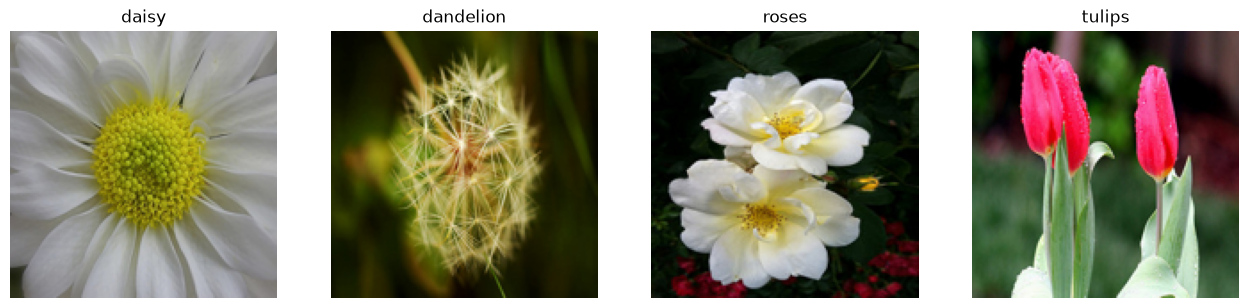

In [35]:
img_h = 150 # image height
img_w = 150 # image Width
batch_size = 64
epochs = 10

# init lists
pictures = []
pics_arr = []
p_class = []

plt.figure(figsize=(20, 5))

data_dir = data_dir / "flower_photos"
for idx, folder in enumerate(data_dir.glob('[!LICENSE]*')):

    cat = list(folder.glob('*.jpg'))

    if not cat:
        continue

    img = PIL.Image.open(str(cat[0])).resize((img_w, img_h))
    pic_arr = np.array(img)
    clss = folder.name

    plt.subplot(1, 5, idx + 1)
    plt.imshow(img)
    plt.title(clss)
    plt.axis('off')

    pictures.append(img)
    pics_arr.append(pic_arr)
    p_class.append(clss)

## Create a Training Set

In [36]:
train_set = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=10,
    image_size=(img_h, img_w),
    batch_size=batch_size,
    label_mode='categorical',
    shuffle=True
)

print("\n")

val_set = image_dataset_from_directory(
    data_dir, validation_split=0.2, subset='validation',
    seed=10, image_size=(img_h, img_w), batch_size=batch_size,
    label_mode='categorical'
)

class_names = dict(enumerate(val_set.class_names))
print(f"\nClasses:\n{class_names}")


Found 3670 files belonging to 5 classes.
Using 2936 files for training.


Found 3670 files belonging to 5 classes.
Using 734 files for validation.

Classes:
{0: 'daisy', 1: 'dandelion', 2: 'roses', 3: 'sunflowers', 4: 'tulips'}


## Building a Classifier

In [37]:
classifier = Sequential()

#### Exercise: Define the first set of convolutional layers

Add the following layers to our classifier:
1. Convolutional layer with input depth equal to 3, 32 5x5 filters, even padding, and relu activation function.
2. Max pooling layer with size 2x2.
3. Convolutional layer with 64 3x3 filters, padding, and relu activation function.
3. Max pooling layer with size 2x2, strides of 2 horizontally and vertically.

In [38]:
classifier.add(
    Conv2D(filters=32, kernel_size=(5,5), padding='same', activation='relu',
    kernel_initializer='he_uniform', input_shape=(img_w, img_h, 3)))
classifier.add(MaxPool2D(2, 2))

classifier.add(
    Conv2D(filters=64, kernel_size=(3,33), padding='same', activation='relu',
    kernel_initializer='he_uniform'))

classifier.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

c:\Users\LEI\Documents\deep-learning-ibm\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Exercise: Add a second set of convolutional layers

Add the following layers to our classifier:
1. Convolutional layer with 32 3x3 filters, even padding, and relu activation function.
2. Max pooling layer with size 2x2, strides of 2 horizontally and vertically.
3. Convolutional layer with 32 3x3 filters, padding, and relu activation function.
3. Max pooling layer with size 2x2, strides of 2 horizontally and vertically.

In [39]:
classifier.add(
    Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation='relu', kernel_initializer='he_uniform'))
classifier.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

classifier.add(
    Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation='relu', kernel_initializer='he_uniform'))
classifier.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

In [40]:
classifier.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 150, 150, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 75, 75, 64)     │       202,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 37, 37, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 18, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 18, 18, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 9, 9, 32)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 232,960 (910.00 KB)

 Trainable params: 232,960 (910.00 KB)

 Non-trainable params: 0 (0.00 B)

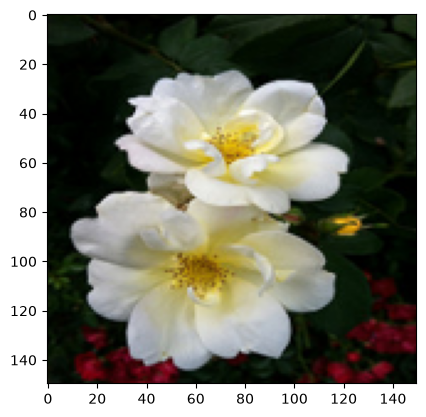

In [41]:
img_tensor = np.array(pics_arr[2], dtype='int')
plt.imshow(img_tensor)

In [42]:
# expand the dimensions
img_tensor = np.expand_dims(img_tensor, axis=0)
y = classifier.predict(img_tensor)
print(f"The predicted output the sample image has a shape of: {y.shape}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
The predicted output the sample image has a shape of: (1, 9, 9, 32)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step


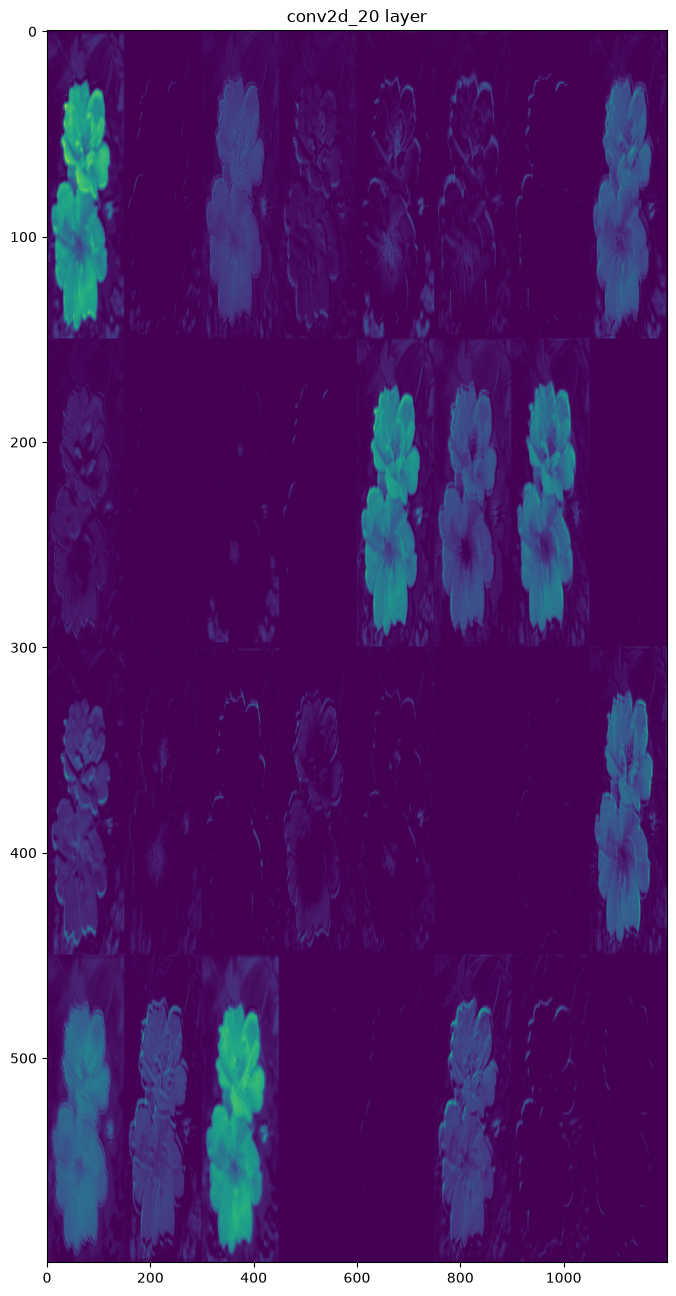

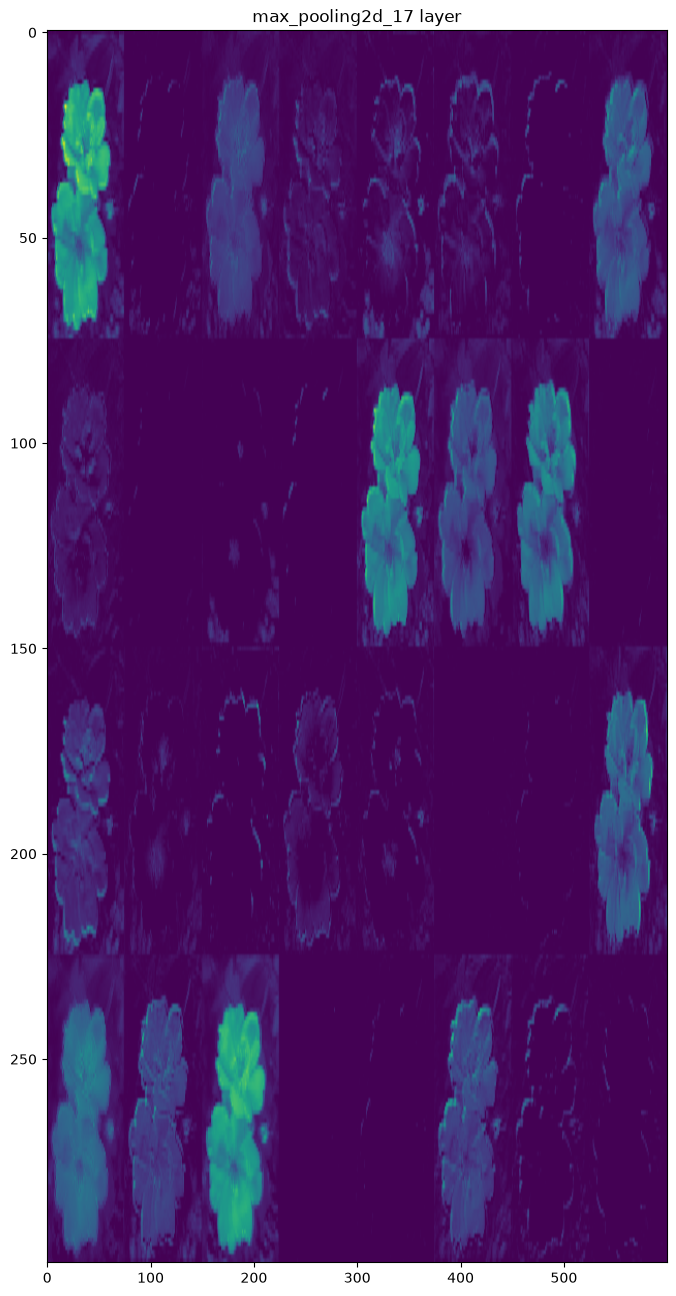

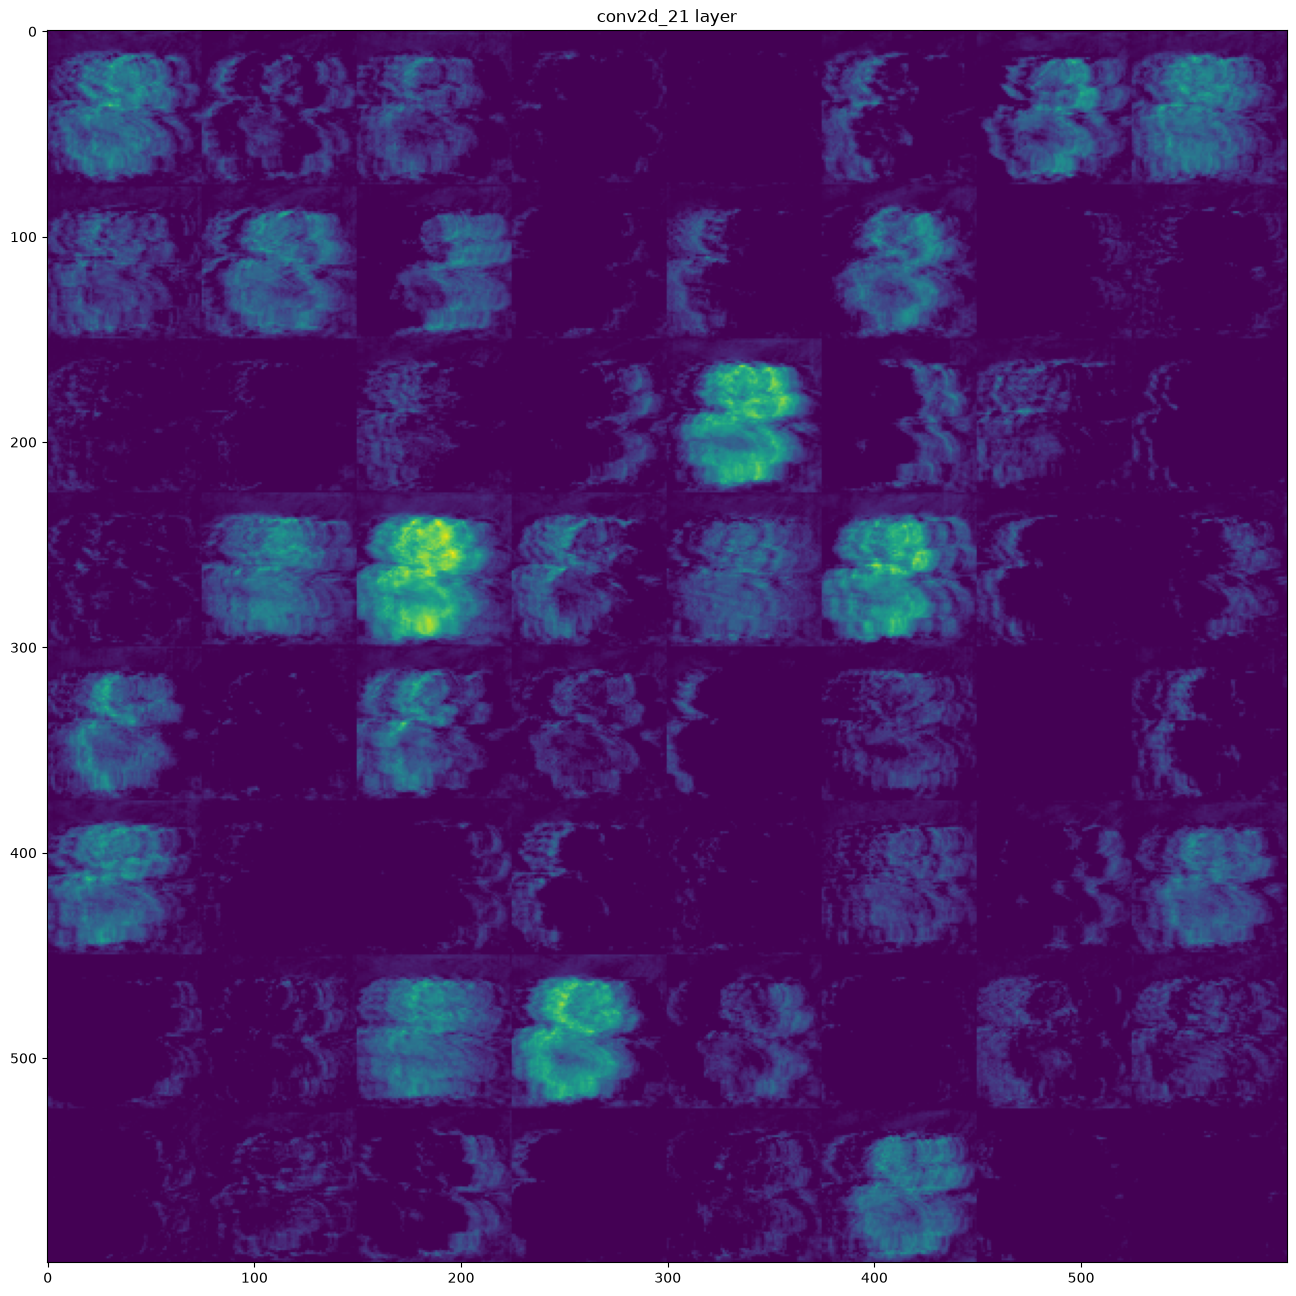

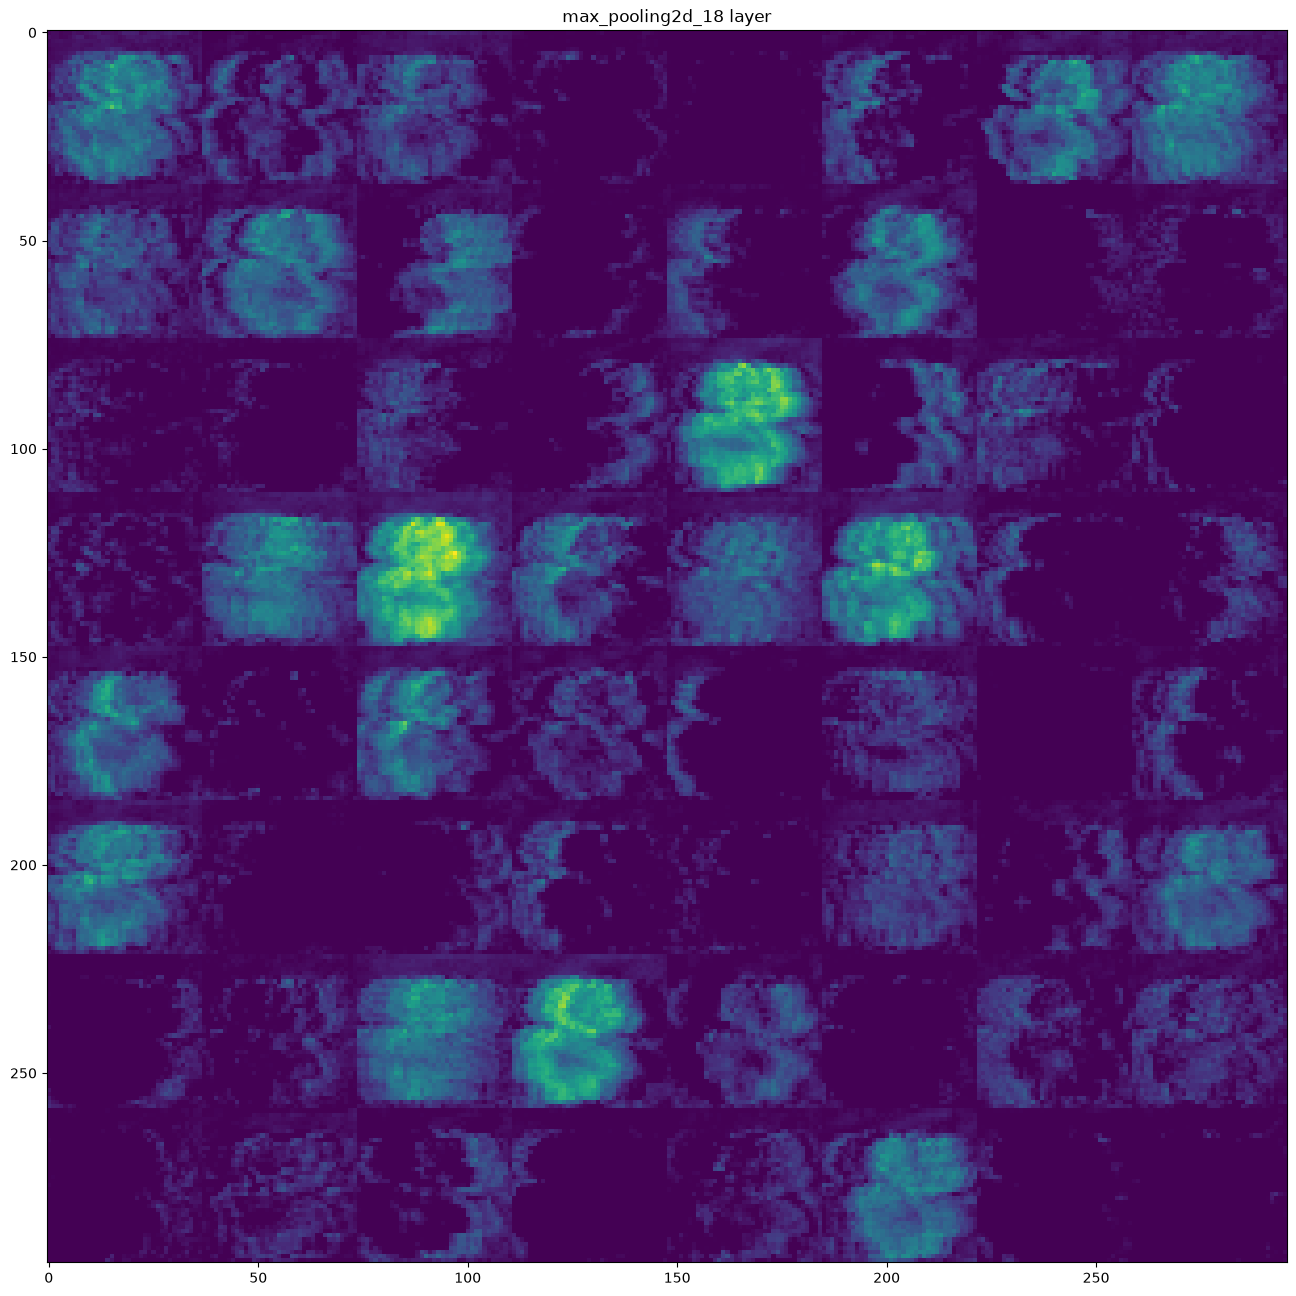

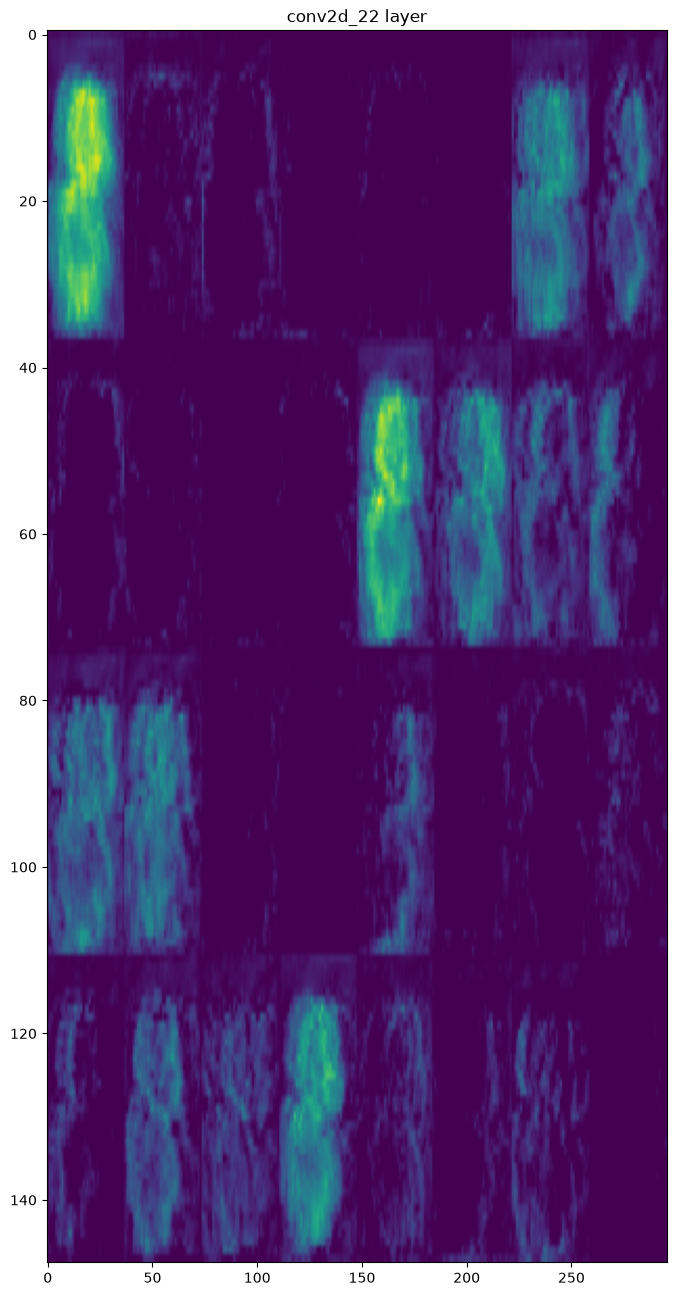

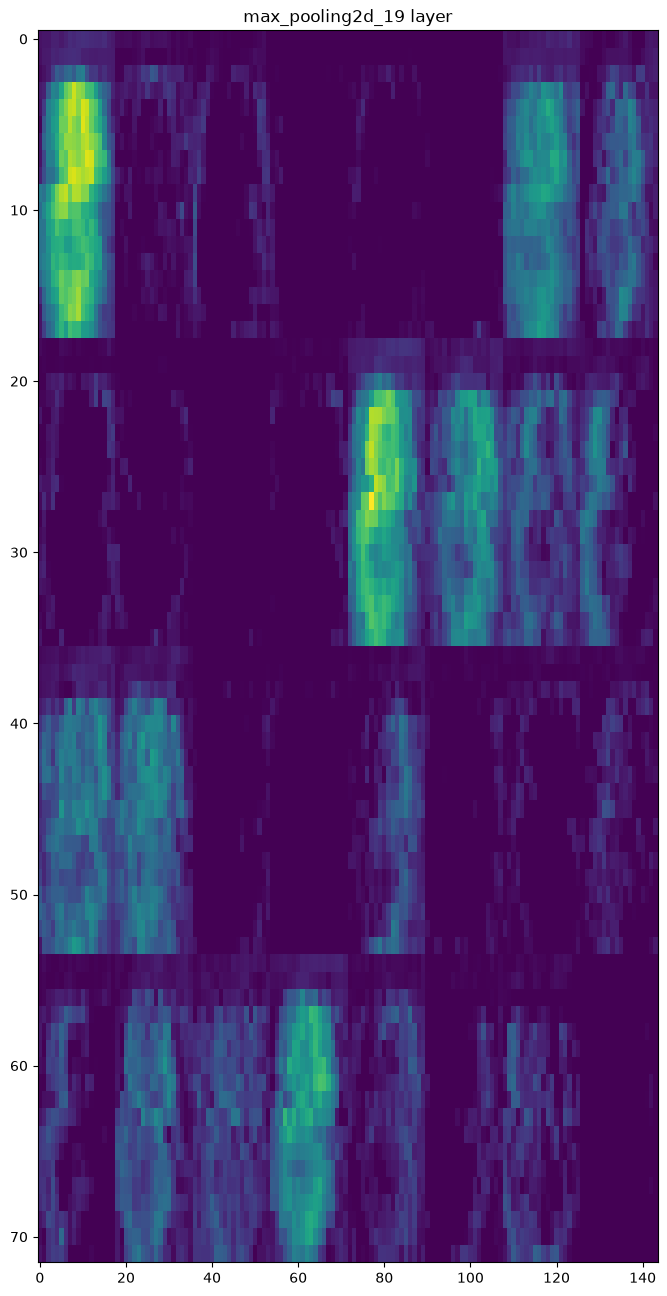

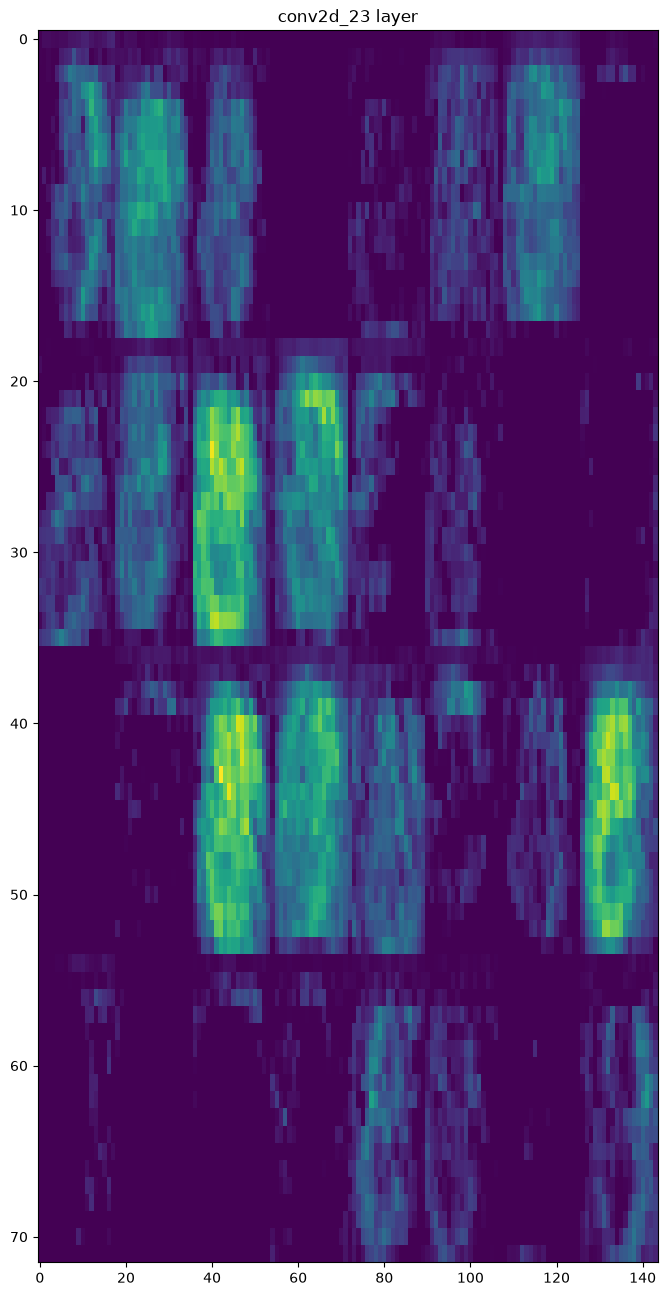

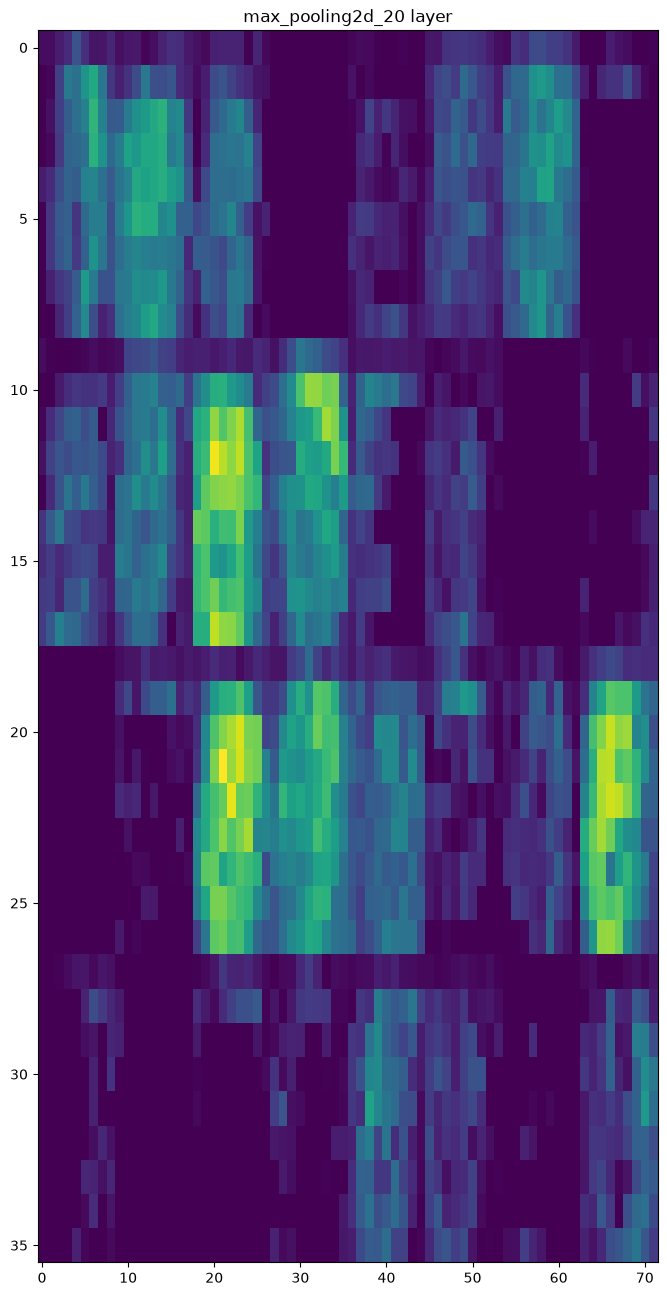

In [52]:
layer_outputs = [layer.output for layer in classifier.layers]

activation_model = Model(inputs=classifier.inputs, outputs=layer_outputs)
activations = activation_model.predict(img_tensor)

plot_activations_multilayer(8, 8, classifier=classifier, activations=activations)

#### Exercise: Add a Flattening layer
From the summary above, we see that the shape of the output of the previous layer is $73\times73\times6$. Thus, the shape of the output of our flattening layer will be  $73\times73\times6 = 31974\times1$.

In [53]:
classifier.add(Flatten())

#### Exercise: Add Dense Layers

Now the last step of building the **classifier** model is adding some fully-connected dense layers:

- Dense layer with 512 units and relu activation function.
- Dense layer with 5 units (because the dataset has 5 classes) and softmax activation function.

In [56]:
classifier.add(Dense(units=512, activation='relu'))
classifier.add(Dense(units=5, activation='softmax'))
classifier.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 150, 150, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 75, 75, 64)     │       202,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 37, 37, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 18, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 18, 18, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 9, 9, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2592)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,327,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,565 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,568,778 (5.98 MB)

 Trainable params: 1,568,778 (5.98 MB)

 Non-trainable params: 0 (0.00 B)

## Compile and Predict using the Model

In [62]:
classifier.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

classifier.fit(
    train_set,
    validation_data=val_set,
    epochs=epochs
)

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 34938s 751s/step - accuracy: 0.2415 - loss: 1.6034 - val_accuracy: 0.2534 - val_loss: 1.6022
Epoch 2/10
 1/46 ━━━━━━━━━━━━━━━━━━━━ 9:53:20 791s/step - accuracy: 0.2344 - loss: 1.6057

: 

: 

In [ ]:
for layer in classifier.layers:
    if 'conv_2d' in layer.name:
        kernels, biases = layer.get_weights()
        print(f"Layer Name: {layer.name} | No. of Kernels: {kernels.shape[-1]} | Kernel Shape: {kernels[:2]} | Kernel Depth: {kernels[2]}")

for layer in classifier.layers:

    if 'conv_2d' in layer.name:

        name = layer.name
        kernels, _ = layer.get_weights()
        k_min, k_max = kernels.min(), kernels.max()
        kernels = (kernels - k_min) / (k_max - k_min)

        for idx in range(4):

            kernel = kernels[:,:,:,idx]

            fig = plt.figure(figsize=(5, 2))
            fig.suptitle(f"{name} | Kernel {idx + 1}")

            for j in range(3):

                plt.subplot(1, 3, j+1)
                plt.imshow(kernel[:,:,j], cmap='gray')
                plt.xticks([])
                plt.yticks([])

In [ ]:
plt.imshow(kernels[:,:,2,3], cmap='gray')

In [ ]:
layer_outputs = [layer.output for layer in classifer.layer]
activation_model = Model(inputs=classifier.input, outputs=layer_outputs)
img_tensor = pics_arr[1]
plt.imshow(np.array(img_tensor, dtype='int'))

In [ ]:
img_tensor = np.expand_dims(img_tensor, axis=0)
activations = activation_model.predict(img_tensor)[:6]
plot_activations(7, 8, classifier, activations)

In [ ]:
y = classifier.predict(img_tensor)
label = class_names[np.argmax(y)]

plt.imshow(img_tensor.reshape((img_w, img_h, 3)).astype('uint8'))
plt.title(f"Predicted Class : {label}")